# 01 · Data audit

**Question:** is the weekly sales history of Distribuidora Valle Central fit for training a demand forecast, and what has to be fixed or excluded first?

Unit of observation: one product × one store × one week. Target: `unidades` (units sold).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import data_prep as dp, plot_style as ps

ps.apply()
pd.options.display.float_format = "{:,.2f}".format
IMG = Path.cwd().parent / "images"
DATA_PATH, DATA_MODE = dp.resolve_data_path()
print(f"Using {DATA_MODE} dataset: {DATA_PATH.name}")

Using full dataset: valle_central_ventas_semanales.csv


In [2]:
raw = dp.load_raw(DATA_PATH)
print(f"Rows: {len(raw):,} · Columns: {raw.shape[1]}")
print(f"Period: {raw.fecha.min().date()} → {raw.fecha.max().date()} ({raw.fecha.nunique()} weeks)")
print(f"Stores: {raw.id_sucursal.nunique()} · Products: {raw.id_producto.nunique()} · Categories: {raw.categoria.nunique()}")
raw.head()

Rows: 560,685 · Columns: 15
Period: 2023-01-02 → 2025-12-22 (156 weeks)
Stores: 12 · Products: 340 · Categories: 10


,fecha,id_sucursal,nombre_sucursal,tipo_sucursal,id_producto,categoria,perecedero,precio,promocion,unidades,stock_inicial,stock_final,es_feriado_temporada,es_quincena,es_diciembre
0,2023-01-02,S01,San José Centro,urbana,P0001,Limpieza,False,"8,607.00",NaN,188,240,52,True,True,False
1,2023-01-02,S01,San José Centro,urbana,P0002,Higiene personal,False,"1,644.00",NaN,221,258,37,True,True,False
2,2023-01-02,S01,San José Centro,urbana,P0003,Carnes,True,"2,316.00",NaN,192,246,54,True,True,False
3,2023-01-02,S01,San José Centro,urbana,P0004,Snacks,False,929.00,NaN,69,83,14,True,True,False
4,2023-01-02,S01,San José Centro,urbana,P0005,Lácteos,True,"2,902.00",NaN,57,73,16,True,True,False


## 1. Missing values and duplicates

In [3]:
missing = (raw.isna().mean() * 100).round(2)
display(missing[missing > 0].rename("% missing").to_frame())
print("Exact duplicate rows:", raw.duplicated().sum())

,% missing
precio,2.07
promocion,32.14


Exact duplicate rows: 25


In [4]:
# Is the missingness in 'promocion' random, or structured in time?
(raw.assign(year=raw.fecha.dt.year)
    .groupby("year")["promocion"].apply(lambda s: s.isna().mean() * 100)
    .rename("% promocion missing").to_frame())

,% promocion missing
year,
2023,100.00
2024,1.89
2025,0.00


**Finding:** `promocion` is missing for *all* of 2023 — it simply wasn't recorded that year. Filling it with `False` alone would claim there were no promotions for a full year, so the cleaning step also adds a `promocion_sin_registro` flag that lets the model tell "no promotion" apart from "unknown". `precio` (~2 % missing) is filled with the last known price of the same product in the same store.

## 2. Data leakage

`stock_inicial` and `stock_final` look like great predictors. The question is whether they would be *available* on Monday, when the planner makes the forecast.

In [5]:
print(raw[["stock_inicial", "stock_final", "unidades"]].corr()["unidades"].round(3))

identity = (raw.stock_final == raw.stock_inicial - raw.unidades).mean() * 100
print(f"\nstock_final == stock_inicial − unidades in {identity:.2f}% of rows")

stock_inicial   0.98
stock_final     0.84
unidades        1.00
Name: unidades, dtype: float64

stock_final == stock_inicial − unidades in 99.97% of rows


- `stock_final` is literally `stock_inicial − unidades`: it's known only after the week's sales. **Deterministic leakage → excluded.**
- `stock_inicial` correlates 0.98 with the target because it *is* the planner's own replenishment decision — the very decision this model is meant to support. Using it would teach the model to copy the planner. **Circular leakage → excluded.**

## 3. Censored demand

In [6]:
zeros = (raw.unidades == 0).sum()
zeros_no_stock = ((raw.unidades == 0) & (raw.stock_inicial == 0)).sum()
sold_out = ((raw.unidades == raw.stock_inicial) & (raw.stock_inicial > 0)).sum()
print(f"Weeks with 0 units sold: {zeros:,} — of which with no stock at all: {zeros_no_stock:,}")
print(f"Weeks that sold out (units == opening stock): {sold_out:,} ({sold_out / len(raw) * 100:.1f}% of rows)")

Weeks with 0 units sold: 3,928 — of which with no stock at all: 3,928
Weeks that sold out (units == opening stock): 468 (0.1% of rows)


Every zero-sales week had zero stock on hand, and another 468 weeks sold out completely (≈0.8 % of rows combined). In those rows we observe *sales*, not *demand* — true demand was at least that high. The share is small, so it's documented as a known limitation (it slightly biases forecasts downward) rather than modeled.

## 4. Coverage by store

In [7]:
coverage = raw.groupby(["id_sucursal", "nombre_sucursal", "tipo_sucursal"]).fecha.agg(first_week="min", weeks="nunique")
coverage

,,,first_week,weeks
id_sucursal,nombre_sucursal,tipo_sucursal,,
S01,San José Centro,urbana,2023-01-02,156
S02,Alajuela Centro,urbana,2023-01-02,156
S03,Cartago Centro,urbana,2023-01-02,156
S04,Heredia Centro,urbana,2023-01-02,156
S05,Desamparados,urbana,2023-01-02,156
S06,San Pedro,urbana,2023-01-02,156
S07,Curridabat,urbana,2023-01-02,156
S08,Escazú,urbana,2023-01-02,156
S09,Grecia,rural,2023-01-02,156


Two stores opened recently (S11 in January 2025, S12 in April 2025), and **both are rural**. They have little history, so any urban-vs-rural error gap could really be a new-vs-established gap. Final metrics are reported for both splits to tell the two apart.

## 5. Target distribution and seasonality

In [8]:
print(raw.unidades.describe().round(1))
print(f"Skewness: {raw.unidades.skew():.2f}")

count   560,685.00
mean         69.70
std          61.30
min           0.00
25%          30.00
50%          53.00
75%          91.00
max       1,661.00
Name: unidades, dtype: float64
Skewness: 2.81


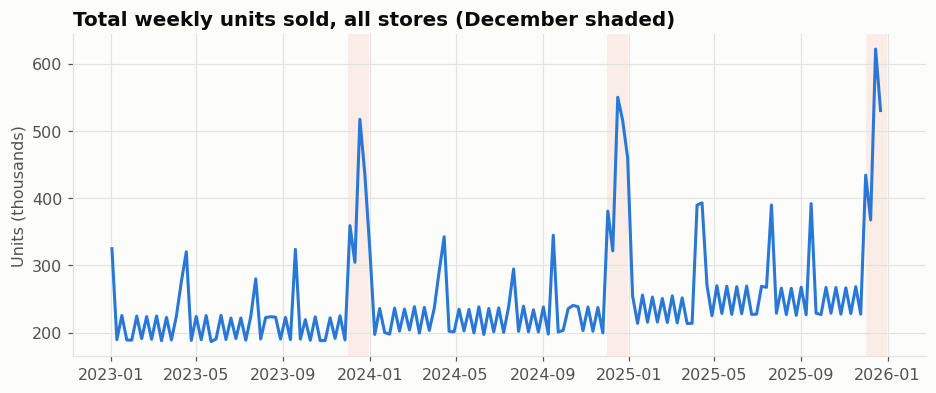

In [9]:
weekly = raw.groupby("fecha").unidades.sum() / 1000

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(weekly.index, weekly.values, color=ps.BLUE)
for year in (2023, 2024, 2025):
    ax.axvspan(pd.Timestamp(f"{year}-12-01"), pd.Timestamp(f"{year}-12-31"), color=ps.ORANGE, alpha=0.10, lw=0)
ax.set_title("Total weekly units sold, all stores (December shaded)")
ax.set_ylabel("Units (thousands)")
ax.set_xlabel("")
fig.savefig(IMG / "weekly_sales.png")
plt.show()

In [10]:
# Average units per product-store-week under each calendar / promotion flag
flags = ["es_diciembre", "es_quincena", "es_feriado_temporada", "promocion"]
rows = []
for f in flags:
    g = raw[raw[f].notna()].groupby(raw[f].astype(str)).unidades.mean()
    rows.append({"flag": f, "mean when True": g.get("True"), "mean when False": g.get("False"),
                 "lift %": (g.get("True") / g.get("False") - 1) * 100})
pd.DataFrame(rows)

,flag,mean when True,mean when False,lift %
0,es_diciembre,123.61,64.82,90.71
1,es_quincena,76.26,63.50,20.09
2,es_feriado_temporada,110.23,63.44,73.77
3,promocion,99.95,66.42,50.48


## Audit summary

| Issue | Decision |
|---|---|
| `stock_final`, `stock_inicial` | Excluded — deterministic and circular leakage |
| `promocion` missing in 2023 | Fill with `False` **plus** a `promocion_sin_registro` flag |
| `precio` ~2 % missing | Last known price of the same product-store |
| 25 exact duplicates | Dropped |
| Sold-out / zero-stock weeks | Kept; documented as censored demand (limitation) |
| New stores S11, S12 | Metrics reported separately for new vs. established stores |
| Right-skewed target, December peaks | MAE as main metric (robust to spikes) + WAPE for comparability across categories |